Let's look at the paper *"Multiomics modeling of the immunome, transcriptome, microbiome, proteome and metabolome adaptations during human pregnancy"* by **Ghaemi et al. 2019** (`task1_multiomics_ghaemi2019multiomics.pdf`).
The idea is to use biological measurements to characterize biological changes during pregnancy.
This includes whether we can predict the gestational age of a mother solely based on the collected biomarkers.

**Note 1**: There is no need to get acquainted with the biological intricacies of multiomics modeling in this exercise. The interesting part is the study design and experimental setup.

## Load the data

Load the data from `multiomics_data.pickle` using `pickle`. You will get a [pandas](https://pandas.pydata.org/docs/user_guide/10min.html) DataFrame containing preprocessed data from the paper (the original data from their paper is a bit messy). The data contains several meta attributes as well as the different modalities.

Meta attributes include:

* `Sex`: sex of the baby
* `timepoint`: 1-3 correspond to the three trimesters, 4 corresponds to postpartum
* `gestational_age`: time of sampling

Modalites are:
    
* `cellfree_rna`
* `metabolomics`
* `microbiome`
* `plasma_luminex`
* `serum_luminex`
* `immune_system`
* `plasma_somalogic`

For more details pleaase see the paper.

In [2]:
# look at the immune system
data_multiomics["immune_system"].head(5)

,0_Bcells,1_CD16+CD56-NKcells,2_CD4+Tcells_mem,3_CD4+Tcells_naive,4_CD4+Tcells,5_CD45RA+Tregs,6_CD45RA-Tregs,7_CD56+CD16-NKcells,8_CD7+NKcells,9_CD8+Tcells_mem,...,524_M-MDSC_STAT5_Unstim,525_mDCs_STAT5_Unstim,526_ncMCs_STAT5_Unstim,527_pDCs_STAT5_Unstim,528_Tbet+CD4+Tcells_mem_STAT5_Unstim,529_Tbet+CD4+Tcells_naive_STAT5_Unstim,530_Tbet+CD8+Tcells_mem_STAT5_Unstim,531_Tbet+CD8+Tcells_naive_STAT5_Unstim,532_TCRgd+Tcells_STAT5_Unstim,533_Tregs_STAT5_Unstim
0,0.053164,0.054978,0.297875,0.136289,0.445832,0.002570,0.013848,0.007052,0.070836,0.118884,...,0.998954,0.953637,1.082629,0.808610,0.504269,0.757424,0.462045,0.454665,0.443859,0.529431
1,0.052857,0.069794,0.279917,0.140350,0.430839,0.002470,0.010923,0.004759,0.080245,0.127831,...,0.930847,0.822618,0.931126,0.728738,0.613059,0.852393,0.506981,0.474408,0.491691,0.574133
2,0.053202,0.050829,0.277997,0.187659,0.479078,0.003473,0.013359,0.005302,0.063781,0.104513,...,1.077824,0.970954,1.011011,0.749277,0.752882,0.813249,0.560379,0.481862,0.505706,0.640245
3,0.049906,0.090496,0.266336,0.156263,0.432904,0.003071,0.014459,0.004318,0.101386,0.115243,...,0.976888,0.918164,1.028114,0.790166,0.505349,0.648406,0.464522,0.445444,0.438285,0.573058
4,0.103067,0.004128,0.162746,0.103950,0.270840,0.003198,0.007988,0.007153,0.090763,0.057064,...,0.890405,0.800468,1.067789,0.563615,0.464563,1.004497,0.378557,0.423530,0.332368,0.447904


## Tasks

### Gestational Age

 **Predict `gestational_age`** with an elastic net model using only the `immune_system` modality.




In [5]:

import pandas as pd
import pickle


# Load data
with open(r"C:\\Users\\Ashil-Rayan\\Downloads\\P129-EvaluationTasks-2025-09-12\\P129-EvaluationTasks\\assets\\task1_multiomics_data.pickle", "rb") as file:
    data_multiomics = pickle.load(file)
# look at the immune system
data_multiomics["immune_system"].head(5)
X = data_multiomics["immune_system"]
y = data_multiomics["gestational_age"]
print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (68, 534)
y shape: (68,)


In [4]:
# ElasticNet has some important hyperparameters (alpha, l1_ratio, max_iter).
# We don’t know the best values in advance, so we use GridSearchCV to try
# many combinations and pick the set that gives the best R² score.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

# Step 1: Grid search for best hyperparameters
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 5, 10],   # strength of regularization
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],  # balance between L1 and L2
    "max_iter": [1000, 5000, 10000]         # max number of iterations
}

elastic = ElasticNet(random_state=42)

grid = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    scoring="r2",  # choose the best parameters based on R²
    cv=5
)

# scale the full dataset before tuning
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

grid.fit(X_scaled, y)
best_params = grid.best_params_
print("Best Parameters (from GridSearch):", best_params)

# Step 2: KFold cross-validation with the best parameters
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = np.empty(len(X), dtype=float)

all_r2, all_mae, all_rmse = [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    # split train/test for this fold
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
    
    # scale train and test separately (to avoid data leakage)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # train ElasticNet with best parameters
    model = ElasticNet(**best_params, random_state=42)
    model.fit(X_train, y_train)
    
    # predict for test set
    y_pred = model.predict(X_test)
    y_pred_all[test_idx] = y_pred
    
    # evaluate this fold
    fold_r2 = r2_score(y_test, y_pred)
    fold_mae = mean_absolute_error(y_test, y_pred)
    fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    all_r2.append(fold_r2)
    all_mae.append(fold_mae)
    all_rmse.append(fold_rmse)
    
    print(f"Fold {fold}: R²={fold_r2:.3f}, MAE={fold_mae:.3f}, RMSE={fold_rmse:.3f}")

# Step 3: Average metrics across folds
print("\nMean R²:", np.mean(all_r2))
print("Mean MAE:", np.mean(all_mae))
print("Mean RMSE:", np.mean(all_rmse))

# Step 4: Spearman correlation between true and predicted values (according the paper)
rho, p = spearmanr(y, y_pred_all)
print(f"Spearman ρ = {rho:.3f}, p-value = {p:.2e}")



c:\Users\Ashil-Rayan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.213e+00, tolerance: 9.258e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ashil-Rayan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.493e+00, tolerance: 9.331e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Ashil-Rayan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

Best Parameters (from GridSearch): {'alpha': 1, 'l1_ratio': 0.9, 'max_iter': 1000}
Fold 1: R²=-0.050, MAE=7.973, RMSE=10.332
Fold 2: R²=0.641, MAE=6.839, RMSE=8.289
Fold 3: R²=0.704, MAE=6.862, RMSE=7.559
Fold 4: R²=0.138, MAE=9.318, RMSE=11.020
Fold 5: R²=0.497, MAE=7.812, RMSE=9.141

Mean R²: 0.3859197701041435
Mean MAE: 7.760673369160438
Mean RMSE: 9.268120037972597
Spearman ρ = 0.545, p-value = 1.53e-06


This task is a regression problem because the goal is to predict a continuous value (gestational age). ElasticNet is a type of linear regression with regularization, and the metrics we used (R², MAE, RMSE, Spearman correlation) are all standard for regression.

The best parameters from GridSearch were alpha = 1, l1_ratio = 0.9, max_iter = 1000, which means the model relies mostly on L1 regularization. The results across the 5 folds show that performance is not stable: R² values range from -0.050 (very poor) to 0.704 (quite good). The mean R² is about 0.39, so the model explains only 39% of the variance. The errors are also large, with MAE ≈ 7.8 and RMSE ≈ 9.3, meaning predictions are off by 7–9 units on average. The Spearman correlation (ρ = 0.545, p < 0.001) shows a moderate positive relationship between predicted and true values.

In summary, the model captures some real signal but still makes large errors, so performance is only moderate. More data, better features, or different models may be needed to improve accuracy.

**Figure 2D:**<br/>
<img src="assets/task1_multiomics_fig2d.jpeg">

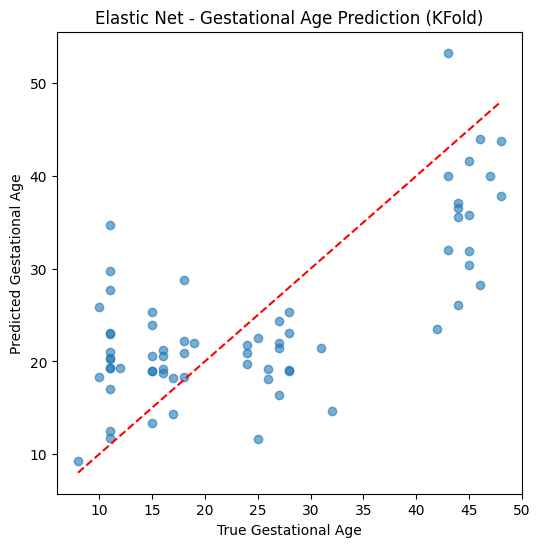

In [6]:

# Step 5: Scatter plot of true vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred_all, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  
plt.xlabel("True Gestational Age")
plt.ylabel("Predicted Gestational Age")
plt.title("Elastic Net - Gestational Age Prediction (KFold)")
plt.show()

The scatter plot shows the relationship between true and predicted gestational age. While the model captures the general trend, many points are far from the red line, indicating that prediction errors are still relatively high.

###
-This dataset has very few samples but a large number of features, which makes overfitting likely and some metrics unstable. In such cases, R² and RMSE can be misleading because they change a lot with small variations. MAE is a better choice since it is easy to interpret and less sensitive to outliers. Spearman’s rank correlation (ρ) is also very important for regression tasks, as it measures whether the model captures the correct overall trend. Therefore, MAE and Spearman ρ together provide the most reliable evaluation for this datase

- I also tested the model using Leave-One-Out Cross-Validation (LOOCV). However, the time complexity was much higher and the improvement in performance was not significant, so it was not worth applying to this dataset. Therefore, I decided to use k-fold cross-validation instead. With LOOCV, the results were: Mean R² = 0.386, Mean MAE = 7.76, Mean RMSE = 9.27, and Spearman ρ = 0.545 (p-value = 1.53e-06).